In [1]:
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense

In [2]:
data = pd.read_csv('heart.csv')
X = data.drop(['output'],axis=1)
Y = data['output']
print("Shape of X = ",X.shape)
print("Shape of Y = ",Y.shape)

Shape of X =  (303, 13)
Shape of Y =  (303,)


In [3]:
################################################
sc = MinMaxScaler()
X = sc.fit_transform(X)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=30)

In [4]:
NNmodel = Sequential()
NNmodel.add(Dense(units=16,activation='relu',input_shape=(13,)))
NNmodel.add(Dense(1,activation='sigmoid'))
opt = keras.optimizers.SGD(learning_rate=0.01)
NNmodel.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])
history = NNmodel.fit(X_train,Y_train,epochs=50,verbose=1)

c:\Python\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4711 - loss: 0.7094
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4711 - loss: 0.7034 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4711 - loss: 0.6986
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4711 - loss: 0.6944
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4669 - loss: 0.6908  
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4669 - loss: 0.6873
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4669 - loss: 0.6841 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4628 - loss: 0.6813  
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4711 - loss: 0.6786 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4917 - loss: 0.6759  
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 0.6735
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5165 - loss: 0.67

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7541 - loss: 0.6119 
Loss of test set =  0.6119486093521118
Accuracy of test set =  0.7540983557701111


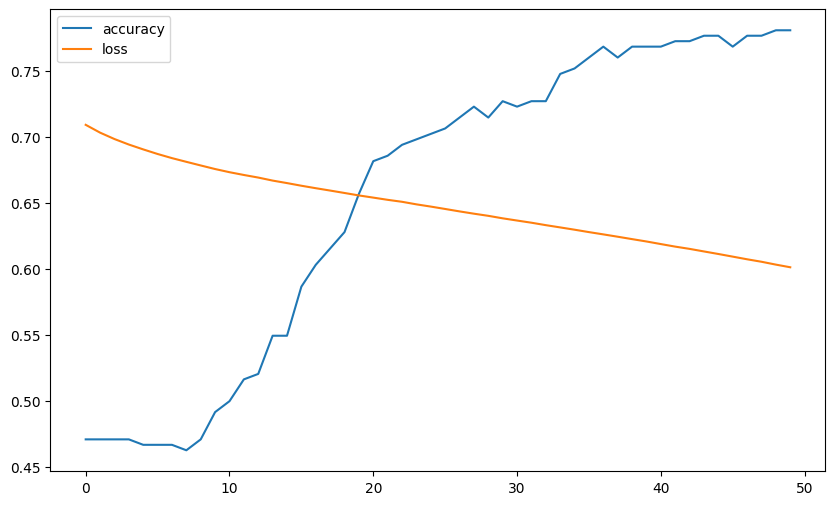

In [5]:
result = NNmodel.evaluate(X_test,Y_test)
print("Loss of test set = ",result[0])
print("Accuracy of test set = ",result[1])

pd.DataFrame(history.history).plot(figsize=(10,6))
plt.show()